In [1]:
import os
import sys
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geo_root = repo_root.parent.parent / 'Data' / 'Geospatial'
gus_root = Path(os.getcwd()).parent.parent.parent.parent / "Data" / "GUS"

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

# import local toolkit (try normal import first, fall back to loading from file)
try:
	import inequality_analyzers as inqA
	import local_utility_functions as luf
except Exception:
	import importlib.util
	toolkit_path = repo_root / 'Code' / 'tools' / 'inequality_analyzers.py'
	if toolkit_path.exists():
		spec = importlib.util.spec_from_file_location("inequality_analyzers", str(toolkit_path))
		stk = importlib.util.module_from_spec(spec)
		spec.loader.exec_module(stk)
	else:
		raise


In [ ]:
# Load df and df_units from previously saved CSVs
df = pd.read_csv(gus_root / "metadata" / "bdl_variables_level6.csv", encoding="utf-8")
df_units = pd.read_csv(gus_root / "metadata" / "bdl_units.csv", encoding="utf-8")
df_units_with_description = df_units[df_units['hasDescription'] == True]

<Axes: >

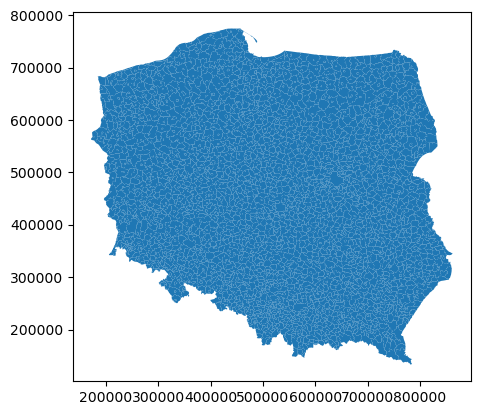

In [3]:
prg_05 = geo_root / "PRG_jednostki_administracyjne_2005"

# Read Obszary.shp file

gdf_2005 = gpd.read_file(prg_05 / "Obszary.shp", encoding="utf-8")
gdf_2005 = gdf_2005.to_crs(epsg=2180)  # Convert to EPSG:2180
gdf_2005.plot()

<Axes: >

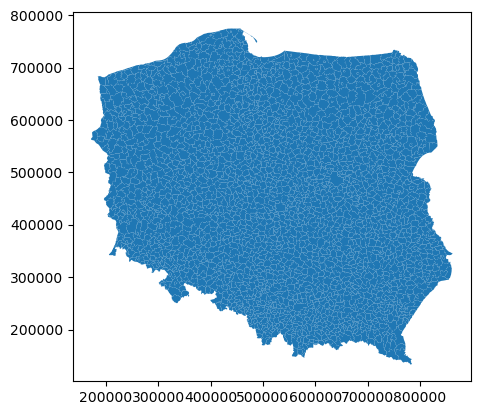

In [4]:
prg_17 = geo_root / "PRG_jednostki_administracyjne_2017"

# Read gminy.shp file with polish characters

gdf_2017 = gpd.read_file(prg_17 / "gminy.shp")
gdf_2017 = gdf_2017.to_crs(epsg=2180)  # Convert to EPSG:2180
gdf_2017.plot()

In [38]:
# Merging gdf_2017 and df_units on "jpt_kod_je" from gdf_2017 and "id" from df_units
# Creating columns "unitId" and "unitName" in gdf_2017 and "jpt_kod_je" in df_units for merging
gdf_2017['unitId'] = np.nan
gdf_2017['unitName'] = np.nan
df_units['jpt_kod_je'] = np.nan
for index, row in df_units.iterrows():
    gdf_code_from_units_id = luf.nuts_code_to_teryt(str(row['id']))
    where = np.where(gdf_2017['jpt_kod_je'].values == gdf_code_from_units_id)[0]
    if len(where) > 0:
        gdf_2017.at[where[0], 'unitId'] = row['id']
        gdf_2017.at[where[0], 'unitName'] = row['name']
        df_units.at[index, 'jpt_kod_je'] = gdf_code_from_units_id
    

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_17616/2389908868.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Bochnia' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gdf_2017.at[where[0], 'unitName'] = row['name']
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_17616/2389908868.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1201011' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_units.at[index, 'jpt_kod_je'] = gdf_code_from_units_id
